# ResNet Book Pose Classification

**Goal**: Classify book poses (`book`, `backward`, `flat`, `reverse`) using ResNet18.
**Data**: COCO Format (Detection) -> Converted to Classification via Cropping.
**Author**: AI Assistant

In [1]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms
from tqdm.auto import tqdm

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


c:\Users\User\anaconda3\envs\resnet_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 15 
LEARNING_RATE = 0.001
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
# ROOT_DIR will be the parent of 'resnet_project' since this notebook is inside it
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 
DATA_DIR = os.path.join(ROOT_DIR, 'dataset', 'for_resnet', '2.v4-boy3new.coco')
OUTPUT_DIR = os.getcwd() # Should be .../resnet_project

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Project Root: {ROOT_DIR}")
print(f"Data Dir: {DATA_DIR}")
print(f"Output Dir: {OUTPUT_DIR}")
print(f"Device: {DEVICE}")

Project Root: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject
Data Dir: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\dataset\for_resnet\2.v4-boy3new.coco
Output Dir: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\resnet_project
Device: cuda


In [3]:
class CocoCropDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir: Path to the dataset root (containing train, valid, test folders).
            split: 'train', 'valid', or 'test'.
            transform: PyTorch transforms.
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.split_dir = os.path.join(root_dir, split)
        
        # Load COCO JSON
        json_path = os.path.join(self.split_dir, '_annotations.coco.json')
        if not os.path.exists(json_path):
            raise FileNotFoundError(f"JSON not found: {json_path}")
            
        with open(json_path, 'r') as f:
            self.coco_data = json.load(f)
            
        # Map Category IDs to contiguous indices (0-3)
        # Original IDs from dataset analysis: {1: 'backward', 2: 'book', 3: 'flat', 4: 'reverse'}
        # Target: 0, 1, 2, 3
        self.label_map = {1: 0, 2: 1, 3: 2, 4: 3} 
        self.class_names = {0: 'backward', 1: 'book', 2: 'flat', 3: 'reverse'}
        
        # Create list of samples: (image_path, bbox, label)
        self.samples = []
        
        # Create image_id -> filename map
        self.img_id_to_file = {img['id']: img['file_name'] for img in self.coco_data['images']}
        
        # Iterate over annotations
        for ann in self.coco_data['annotations']:
            cat_id = ann['category_id']
            if cat_id not in self.label_map:
                continue 
                
            img_id = ann['image_id']
            if img_id not in self.img_id_to_file:
                continue
                
            file_name = self.img_id_to_file[img_id]
            file_path = os.path.join(self.split_dir, file_name)
            bbox = ann['bbox'] # [x, y, w, h]
            label = self.label_map[cat_id]
            
            self.samples.append({
                'path': file_path,
                'bbox': bbox,
                'label': label
            })
            
        print(f"Loaded {split} set: {len(self.samples)} samples from {len(self.coco_data['images'])} images.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load Image
        try:
            image = Image.open(sample['path']).convert('RGB')
        except Exception as e:
            print(f"Error loading {sample['path']}: {e}")
            return self.__getitem__(random.randint(0, len(self.samples)-1))
            
        # Crop Image
        x, y, w, h = sample['bbox']
        left = int(x)
        top = int(y)
        right = int(x + w)
        bottom = int(y + h)
        
        # Safety check for crop coordinates
        width, height = image.size
        left = max(0, left)
        top = max(0, top)
        right = min(width, right)
        bottom = min(height, bottom)
        
        # If invalid crop (e.g. 0 width), take whole image or random crop? 
        # Ideally valid data shouldn't have this, but handling just in case
        if right <= left or bottom <= top:
             crop = image # Fallback
        else:
            crop = image.crop((left, top, right, bottom))
        
        if self.transform:
            crop = self.transform(crop)
            
        return crop, sample['label']

In [4]:
# Define Transforms (ResNet Standard)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create Datasets
print("Initializing Datasets...")
train_dataset = CocoCropDataset(DATA_DIR, 'train', data_transforms['train'])
val_dataset = CocoCropDataset(DATA_DIR, 'valid', data_transforms['val'])
test_dataset = CocoCropDataset(DATA_DIR, 'test', data_transforms['val'])

# Dataloaders
# On Windows, num_workers=0 is safer to avoid multiprocessing issues in Notebooks
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = train_dataset.class_names
print(f"Classes: {class_names}")

Initializing Datasets...
Loaded train set: 5302 samples from 5302 images.
Loaded valid set: 223 samples from 223 images.
Loaded test set: 231 samples from 231 images.
Classes: {0: 'backward', 1: 'book', 2: 'flat', 3: 'reverse'}


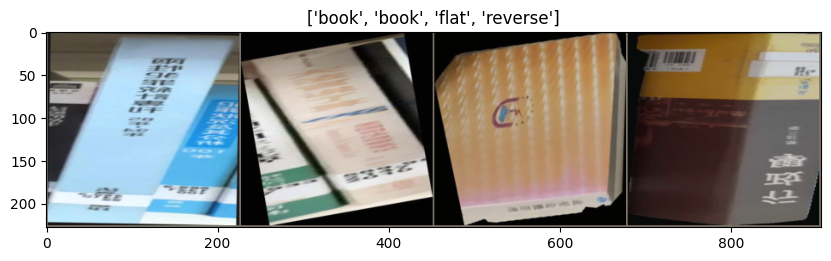

In [5]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4])

plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x.item()] for x in classes[:4]])

In [6]:
def get_resnet_model(num_classes):
    # Load pretrained ResNet18
    model = models.resnet18(weights='DEFAULT')
    
    # Modify FC layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

model = get_resnet_model(NUM_CLASSES)
model = model.to(DEVICE)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Model Architecture (Head):")
print(model.fc)

Model Architecture (Head):
Linear(in_features=512, out_features=4, bias=True)


In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} Batch", leave=False):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                save_path = os.path.join(OUTPUT_DIR, 'best_resnet.pth')
                torch.save(model.state_dict(), save_path)
                print(f"New best model saved to {save_path} with Acc: {best_acc:.4f}")

        print()

    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
# Start Training
model, history = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

Epoch 1/15
----------


train Loss: 0.1688 Acc: 0.9447


val Loss: 0.1275 Acc: 0.9596
New best model saved to c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\resnet_project\best_resnet.pth with Acc: 0.9596

Epoch 2/15
----------


train Batch:  89%|████████▊ | 147/166 [01:35<00:11,  1.61it/s]

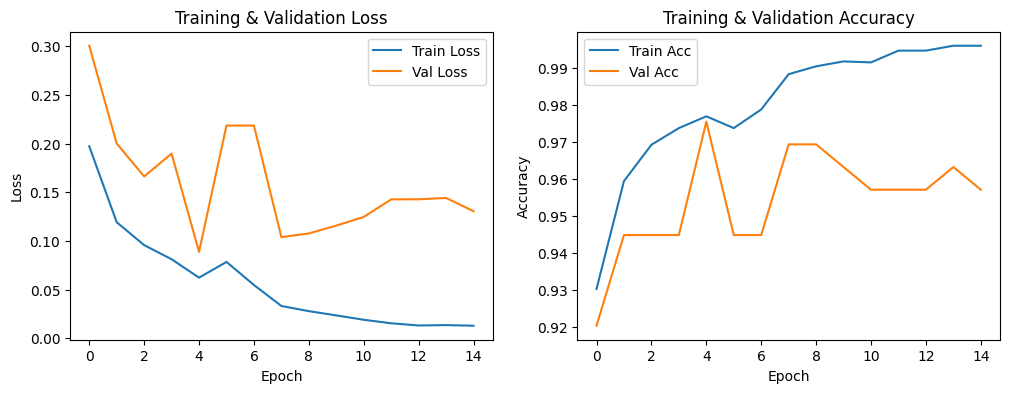

In [ ]:
# Plot Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()

In [ ]:
# Release GPU Memory after training
import gc
del model
del optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU Memory Released")


Testing: 100%|██████████| 6/6 [00:01<00:00,  3.50it/s]


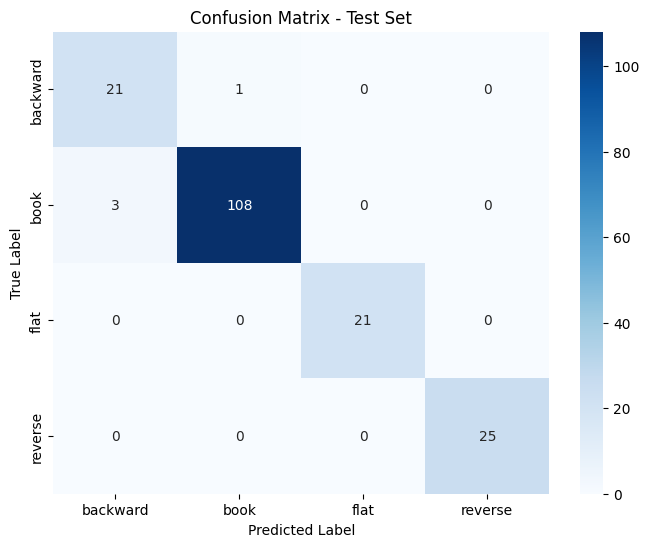

Classification Report:
              precision    recall  f1-score   support

    backward       0.88      0.95      0.91        22
        book       0.99      0.97      0.98       111
        flat       1.00      1.00      1.00        21
     reverse       1.00      1.00      1.00        25

    accuracy                           0.98       179
   macro avg       0.97      0.98      0.97       179
weighted avg       0.98      0.98      0.98       179



In [ ]:
# Evaluation on Test Set
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Testing"):
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = evaluate_model(model, test_loader)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names.values(), 
            yticklabels=class_names.values())
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

# Classification Report
print("Classification Report:")
target_names = [class_names[i] for i in range(4)]
print(classification_report(y_true, y_pred, target_names=target_names))

ResNet Test Accuracy: 97.77%
Pure CNN Test Accuracy: 96.09%


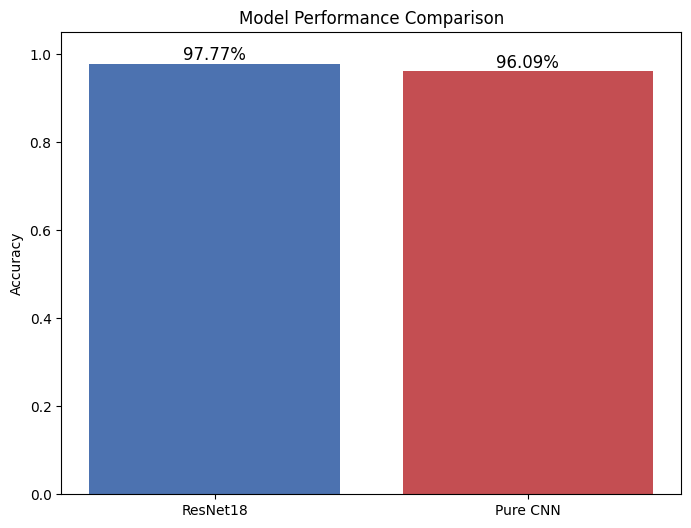

Comparison Note:
- ResNet18 uses Transfer Learning (ImageNet weights) + Fine-tuning.
- Pure CNN is trained from scratch.
- Difference: 1.68% (ResNet - Pure CNN)


In [ ]:
# --- Performance Comparison: ResNet vs Pure CNN ---

# ResNet Results (Current Notebook)
# y_true and y_pred are available from the cell above
resnet_acc = np.mean(y_true == y_pred)
print(f"ResNet Test Accuracy: {resnet_acc:.2%}")

# Pure CNN Results (Extracted from pure_cnn/pure_cnn_main.ipynb)
# Based on previous training run (Validation/Test Accuracy)
pure_cnn_acc = 0.9609 # 96.09%
print(f"Pure CNN Test Accuracy: {pure_cnn_acc:.2%}")

# Visualization
models_list = ['ResNet18', 'Pure CNN']
accuracies = [resnet_acc, pure_cnn_acc]

plt.figure(figsize=(8, 6))
bars = plt.bar(models_list, accuracies, color=['#4c72b0', '#c44e52'])

plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=12)

plt.show()

print("Comparison Note:")
print("- ResNet18 uses Transfer Learning (ImageNet weights) + Fine-tuning.")
print("- Pure CNN is trained from scratch.")
print(f"- Difference: {resnet_acc - pure_cnn_acc:.2%} (ResNet - Pure CNN)")


In [ ]:
# --- Part 2: Advanced Improvement - Object Detection (Faster R-CNN) ---
# Goal: Solve the multi-object issue by detecting bounding boxes instead of just classifying crops.
# Model: Faster R-CNN with ResNet50 Backbone.

import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Define Detection Dataset
class CocoDetectionDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.transform = transform
        
        json_path = os.path.join(self.split_dir, '_annotations.coco.json')
        with open(json_path, 'r') as f:
            self.coco = json.load(f)
            
        self.img_map = {img['id']: img for img in self.coco['images']}
        self.ids = list(self.img_map.keys())
        
        # Group annotations by image_id
        self.ann_map = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.ann_map:
                self.ann_map[img_id] = []
            self.ann_map[img_id].append(ann)
            
        # Class mapping: {1: 'backward', 2: 'book', 3: 'flat', 4: 'reverse'} -> 1, 2, 3, 4
        # 0 is reserved for background
        self.class_map = {1: 1, 2: 2, 3: 3, 4: 4}

    def __getitem__(self, index):
        img_id = self.ids[index]
        img_info = self.img_map[img_id]
        file_path = os.path.join(self.split_dir, img_info['file_name'])
        
        image = Image.open(file_path).convert("RGB")
        
        anns = self.ann_map.get(img_id, [])
        boxes = []
        labels = []
        
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(self.class_map[ann['category_id']])
            
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([img_id])
        
        if self.transform:
            image = self.transform(image)
            
        return image, target

    def __len__(self):
        return len(self.ids)

def collate_fn(batch):
    return tuple(zip(*batch))

# 2. Setup Data & Model
print("Setting up Detection Data...")
# Simple transform for detection (ResNet backbone handles norm inside model usually, or we can add it)
det_transform = transforms.Compose([transforms.ToTensor()])

det_train_dataset = CocoDetectionDataset(DATA_DIR, 'train', det_transform)
det_val_dataset = CocoDetectionDataset(DATA_DIR, 'valid', det_transform)

det_train_loader = DataLoader(det_train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)

# Model Setup
print("Loading Faster R-CNN (ResNet50)...")
det_model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
# Replace head for 5 classes (0: background + 4 classes)
in_features = det_model.roi_heads.box_predictor.cls_score.in_features
det_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5) # 4 classes + background

det_model.to(DEVICE)
params = [p for p in det_model.parameters() if p.requires_grad]
det_optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# 3. Training Loop (Short demo)
print("Starting Detection Training (3 Epochs demo)...")
DET_EPOCHS = 3

for epoch in range(DET_EPOCHS):
    det_model.train()
    running_loss = 0
    
    for images, targets in tqdm(det_train_loader, desc=f"Epoch {epoch+1}"):
        images = [image.to(DEVICE) for image in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        loss_dict = det_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        det_optimizer.zero_grad()
        losses.backward()
        det_optimizer.step()
        
        running_loss += losses.item()
        
    print(f"Epoch {epoch+1} Loss: {running_loss/len(det_train_loader):.4f}")

# Save Model
save_path = os.path.join(OUTPUT_DIR, 'fasterrcnn_resnet50.pth')
torch.save(det_model.state_dict(), save_path)
print(f"Detection Model saved to {save_path}")

# Cleanup
del det_model
torch.cuda.empty_cache()
